# Semi-Supervised CIFAR-10 Classification — CLIP-based Pipeline (v3)

**研究の核心主張**: ラベル付きデータ **500件のみ** から、CLIP事前学習特徴量・疑似ラベリング・特徴空間データ拡張を組み合わせることで、小データ量下でも高精度な分類器を構築できることを示す。

**v2 (MNIST/GAN版) からの主な変更点:**
- データセットを MNIST → **CIFAR-10** に変更（タスク難易度を上げ、手法間の差が見えるようにする）
- バックボーンを WideResNet from-scratch SimCLR → **frozen CLIP (ViT-B/32) + 軽量Adapter (対照学習)** に変更
  - 500枚程度でfrom-scratch学習するより、4億組で事前学習済みのCLIP特徴の方が圧倒的に強い
  - Adapterはunlabeledデータのみで対照学習し、CLIP特徴をCIFAR-10ドメインに適合させる（追加コストはほぼゼロ）
- 疑似ラベリングを **学習可能GCN + CLIP zero-shotテキスト分類のアンサンブル** に強化
  - 画像内部表現（GCN）と言語で定義されたクラス概念（zero-shot）という異質な情報源を組み合わせる
- 生成モデル(cVAE+GAN)による画像生成を廃止し、**CLIP特徴空間でのManifold Mixup** に置き換え
  - 画像生成は難易度が高くリスキー。特徴空間でのMixupは軽量かつ安定
- FixMatch式 weak/strong consistency は維持（疑似ラベルの安定化に有効なため）
- 最後に、baseline CNN・CLIP supervised-only との簡易比較を実施

**Flow:**
- Stage 1: CLIP (frozen) + Adapter 対照学習 (unlabeled含む全画像)
- Stage 1b: 疑似ラベリング (学習可能GCN + CLIP zero-shot のアンサンブル、Top-K + 信頼度フロアで confident 選別)
- Stage 2: CLIP特徴空間 Manifold Mixup (ラベル付き・疑似ラベルありサンプルのペア合成)
- Stage 3: 分類器ヘッド (CLIP特徴→MLP) 学習。labeled CE + 疑似ラベルCE + FixMatch consistency + feature mixup
- Inference: SWA/EMA + TTA (5 aug views → softmax avg)
- 比較: baseline CNN (from scratch) / CLIP supervised-only (疑似ラベルなし) との対比


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torch.optim.swa_utils import AveragedModel, SWALR
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import numpy as np
import random
import math
import copy
import os
from dataclasses import dataclass, field
from typing import Optional, Tuple, List
from tqdm.auto import tqdm
import ssl
import warnings
warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context

# CLIP (open_clip): pip install open_clip_torch
import open_clip

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## Config

In [2]:
@dataclass
class Config:
    # ============================================================
    # Data
    # ============================================================
    n_labeled:        int   = 500
    n_unlabeled:      int   = 3000   # MNIST版の規模感を踏襲
    n_classes:        int   = 10
    img_size:         int   = 224    # CLIP ViT-B/32 の入力解像度
    val_ratio:        float = 0.2    # labeled を 80/20 で train/val 分割

    cifar10_classes: Tuple[str, ...] = (
        "airplane", "automobile", "bird", "cat", "deer",
        "dog", "frog", "horse", "ship", "truck")

    # ============================================================
    # Stage 1: CLIP backbone + lightweight contrastive adapter
    # ============================================================
    clip_model_name:  str   = "ViT-B-32"
    clip_pretrained:  str   = "openai"
    clip_feat_dim:    int   = 512    # ViT-B/32 の出力次元

    # Adapter: CLIP特徴の上に乗せる小さなprojection (frozen CLIP, train adapter)
    adapter_hidden:   int   = 256
    adapter_out:      int   = 128
    adapter_epochs:   int   = 60
    adapter_lr:       float = 1e-3
    adapter_batch:    int   = 128
    adapter_temp:     float = 0.5    # NT-Xent温度

    # ============================================================
    # Stage 1b: Pseudo-labeling
    # 学習可能GCN (画像内部表現ベース) + CLIP zero-shot (言語ベース) の
    # アンサンブルに固定。手法の切り替えは行わない (ensemble_pseudo_label が常に両方を計算し混合する)。
    # ============================================================
    lp_k:             int   = 15
    lp_alpha:         float = 0.90
    lp_iters:         int   = 60
    lp_topk_init:     int   = 20
    lp_topk_max:      int   = 60
    lp_conf_floor:    float = 0.55   # CIFAR-10は500枚だとMNISTより信頼度が出にくいため緩和

    # GCN (学習可能な類似グラフ伝播)
    gcn_hidden:       int   = 128
    gcn_epochs:       int   = 150
    gcn_lr:           float = 5e-3
    gcn_dropout:      float = 0.3

    # Zero-shot ensemble の重み (CLIP特徴kNN/LP の確率と zero-shot 確率を混合)
    zs_ensemble_w:    float = 0.4    # 0=LPのみ, 1=zero-shotのみ

    pseudo_refresh:   int   = 20     # epoch間隔で再計算

    # ============================================================
    # Stage 2: CLIP特徴空間でのデータ拡張 (Manifold Mixup)
    # ============================================================
    use_feature_mixup: bool  = True
    mixup_alpha:       float = 0.4   # Beta(alpha, alpha)
    mixup_pairs_per_epoch: int = 4   # 1 epochあたり実データ数の何倍の合成ペアを作るか

    # ============================================================
    # Stage 3: 分類器 (CLIP特徴 -> MLP head)
    # ============================================================
    cls_hidden:       int   = 256
    cls_dropout:      float = 0.2
    cls_epochs:       int   = 200
    cls_lr:           float = 1e-3
    cls_batch:        int   = 128
    fixmatch_thresh:  float = 0.85   # 疑似ラベルconfidenceの下限 (再学習時のconsistency用)
    fixmatch_temp:    float = 0.5
    label_smoothing:  float = 0.1

    lam_pseudo:       float = 0.5
    lam_mixup:        float = 0.5

    # EMA / SWA
    ema_decay:        float = 0.999
    swa_start:        float = 0.75

    # Logging
    log_interval:     int   = 10

    device: str = DEVICE

cfg = Config()

## データ読み込み (CIFAR-10, stratified labeled/unlabeled/val split)

In [3]:
class CIFARSemiDataset(Dataset):
    def __init__(self, images: torch.Tensor, labels: torch.Tensor):
        self.images = images
        self.labels = labels
    def __len__(self): return len(self.images)
    def __getitem__(self, i): return self.images[i], self.labels[i]


def load_cifar10(cfg: Config):
    """
    CIFAR-10 を読み込み、labeled を stratified に train_l / val_l へ分割。
    unlabeled は labeled とは独立したサブセットから sampling。
    test は返すが最後の評価にのみ使う。

    画像は CLIP の前処理 (Resize 224 + CLIP正規化) に合わせる。
    augmentation (weak/strong) は別セルで定義し、ここでは「素の」テンソルのみ保持する
    (0-1 range, リサイズ後)。CLIP正規化は特徴抽出関数の内部で行う。
    """
    tf = T.Compose([
        T.Resize(cfg.img_size),
        T.ToTensor(),
    ])
    full_train = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=tf)
    test_ds    = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf)

    per_class = cfg.n_labeled // cfg.n_classes
    labeled_idx, unlabeled_idx = [], []
    counts = {c: 0 for c in range(cfg.n_classes)}
    perm = torch.randperm(len(full_train)).tolist()
    for i in perm:
        _, lbl = full_train[i]
        if counts[lbl] < per_class:
            labeled_idx.append(i); counts[lbl] += 1
        elif len(unlabeled_idx) < cfg.n_unlabeled:
            unlabeled_idx.append(i)
        if len(labeled_idx) == cfg.n_labeled and len(unlabeled_idx) == cfg.n_unlabeled:
            break

    def collect(ds, idx, mask_label=False):
        imgs, lbls = [], []
        for i in idx:
            im, lb = ds[i]
            imgs.append(im)
            lbls.append(-1 if mask_label else lb)
        return torch.stack(imgs), torch.tensor(lbls)

    lx, ly = collect(full_train, labeled_idx)
    ux, _  = collect(full_train, unlabeled_idx, mask_label=True)

    # --- Stratified train/val split of labeled data ---
    val_per_class = max(1, int(per_class * cfg.val_ratio))
    train_idx, val_idx = [], []
    vcounts = {c: 0 for c in range(cfg.n_classes)}
    lperm = torch.randperm(len(lx)).tolist()
    for i in lperm:
        c = ly[i].item()
        if vcounts[c] < val_per_class:
            val_idx.append(i); vcounts[c] += 1
        else:
            train_idx.append(i)

    lx_train, ly_train = lx[train_idx], ly[train_idx]
    lx_val,   ly_val   = lx[val_idx],   ly[val_idx]

    # test (10000件) はメモリ節約のため必要時にバッチで処理する想定だが、
    # ここでは MNIST版と同様に一括 tensor 化する (CIFAR-10 32x32->224x224 でも
    # 10000枚 * 3*224*224*4bytes ≈ 6GB弱になるため、float16 で保持しメモリを抑える)。
    test_imgs = torch.stack([test_ds[i][0] for i in range(len(test_ds))]).half()
    test_lbls = torch.tensor([test_ds[i][1] for i in range(len(test_ds))])

    print(f"Labeled train: {len(lx_train)}, Labeled val: {len(lx_val)}, "
          f"Unlabeled: {len(ux)}, Test: {len(test_imgs)}")
    return lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls

lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls = load_cifar10(cfg)


100%|██████████| 170M/170M [00:10<00:00, 16.1MB/s] 


Labeled train: 400, Labeled val: 100, Unlabeled: 3000, Test: 10000


## Augmentation (Weak / Strong, FixMatch式分離)

In [4]:
# ============================================================
# Augmentation
# ------------------------------------------------------------
# v2 (MNIST/GAN版) では DiffAugment + ADA + weak/strong 分離を
# Discriminator の学習安定化のために使っていたが、v3 では GAN を
# 廃止したため、augmentation の役割は以下の2つに単純化される:
#   weak   : 疑似ラベルの「決定」に使う (FixMatchの思想を継続)
#   strong : 実際の分類器学習に使う (RandAugment相当)
# CLIP の事前学習分布を大きく破壊しないよう、color jitter は
# 控えめにする (CLIPは色情報への依存が大きいため過度な変形は逆効果)。
# ============================================================

_weak_tf = T.Compose([
    T.RandomCrop(cfg.img_size, padding=16, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
])

_strong_tf = T.Compose([
    T.RandomCrop(cfg.img_size, padding=16, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(0.3, 0.3, 0.3, 0.05)], p=0.8),
    T.RandomGrayscale(p=0.1),
])


def weak_aug(x: torch.Tensor) -> torch.Tensor:
    x = x.float()
    return torch.stack([_weak_tf(img) for img in x])


def strong_aug(x: torch.Tensor) -> torch.Tensor:
    x = x.float()
    return torch.stack([_strong_tf(img) for img in x])


# ---------- Mixup / CutMix (画像レベル; 分類器学習の補助として残す) ----------
def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = x.shape
    cr = math.sqrt(1 - lam); ch = int(H * cr); cw = int(W * cr)
    cx = random.randint(0, W); cy = random.randint(0, H)
    x1 = max(0, cx - cw // 2); x2 = min(W, cx + cw // 2)
    y1 = max(0, cy - ch // 2); y2 = min(H, cy + ch // 2)
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    idx = torch.randperm(B, device=x.device)
    out = x.clone(); out[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    return out, y, y[idx], lam

def mix_criterion(crit, pred, ya, yb, lam):
    return lam * crit(pred, ya) + (1 - lam) * crit(pred, yb)


def get_cls_view(x, y, epoch, cfg, total_epochs):
    """Curriculum: 序盤は素の weak aug、後半に mixup/cutmix を混ぜる。"""
    x = weak_aug(x)
    frac = epoch / max(1, total_epochs)
    if frac < 0.3:
        return x, y, y, 1.0
    if random.random() < 0.5:
        fn = mixup if random.random() < 0.5 else cutmix
        return fn(x, y)
    return x, y, y, 1.0


## Stage 1: CLIP backbone (frozen) + 軽量 Adapter の対照学習

In [5]:
# ================================================================
# CLIP backbone (frozen) + 軽量 Adapter
# ----------------------------------------------------------------
# 狙い:
#   CLIP (OpenAI, 4億組の画像-テキストで学習済み) の汎用特徴量は
#   強力だが、CIFAR-10 のような特定ドメインに最適化されていない。
#   500枚のラベル付きデータだけで CLIP 全体を fine-tune するのは
#   過学習のリスクが高いので、CLIP は完全に凍結し、その上に
#   小さな MLP (adapter) を載せて、3000枚の unlabeled データで
#   対照学習 (SimCLR式 NT-Xent) のみ行う。
#   これにより「事前学習モデルそのまま」よりドメインに適合した
#   特徴量を、ラベルなしデータだけで追加コストほぼゼロで得る。
# ================================================================

class CLIPBackbone(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        model, _, preprocess = open_clip.create_model_and_transforms(
            cfg.clip_model_name, pretrained=cfg.clip_pretrained)
        self.visual = model.visual
        for p in self.visual.parameters():
            p.requires_grad_(False)
        self.visual.eval()
        # CLIP公式の正規化値 (open_clipのpreprocessから抜き出し)
        self.register_buffer(
            "mean", torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1))
        self.register_buffer(
            "std", torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1))
        self.feat_dim = cfg.clip_feat_dim

    @torch.no_grad()
    def forward(self, x):
        """x: (B,3,H,W) in [0,1] range (any dtype). CLIP正規化を内部で適用して特徴を返す。"""
        x = x.float()
        x = (x - self.mean) / self.std
        return self.visual(x).float()


class Adapter(nn.Module):
    """CLIP特徴 -> 小MLP -> 対照学習用projection。CLIP特徴自体はskip connectionで保持する。"""
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.clip_feat_dim, cfg.adapter_hidden), nn.ReLU(True),
            nn.Linear(cfg.adapter_hidden, cfg.clip_feat_dim))
        self.projector = nn.Sequential(
            nn.Linear(cfg.clip_feat_dim, cfg.clip_feat_dim), nn.ReLU(True),
            nn.Linear(cfg.clip_feat_dim, cfg.adapter_out))
        self.residual_scale = nn.Parameter(torch.tensor(0.1))

    def adapt(self, clip_feat):
        """ドメイン適合済みの特徴 (clip_feat と同次元、以降の全処理はこれを使う)。"""
        return clip_feat + self.residual_scale * self.net(clip_feat)

    def forward(self, clip_feat):
        """対照学習用の正規化projection。"""
        return F.normalize(self.projector(self.adapt(clip_feat)), dim=-1)


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.T = temperature
    def forward(self, z1, z2):
        N = z1.size(0); z = torch.cat([z1, z2], 0)
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1) / self.T
        mask = torch.eye(2 * N, device=z.device).bool()
        sim.masked_fill_(mask, -1e9)
        tgt = torch.arange(N, device=z.device); tgt = torch.cat([tgt + N, tgt])
        return F.cross_entropy(sim, tgt)


@torch.no_grad()
def extract_clip_features(clip_model, imgs, batch=128, device=DEVICE):
    """画像テンソル (0-1, CPU/half可) -> CLIP特徴 (CPU float32) を一括抽出。"""
    clip_model.eval()
    feats = []
    for i in range(0, len(imgs), batch):
        x = imgs[i:i + batch].float().to(device)
        feats.append(clip_model(x).cpu())
    return torch.cat(feats, 0)


def train_adapter(cfg, clip_model, lx_train, ux):
    """
    Stage 1: Adapter の対照学習。
    labeled+unlabeled の画像 (ラベル情報は使わない) に weak/strong augment をかけ、
    NT-Xent で「同じ画像の異なる view は近く」を学習する。
    CLIP本体は凍結、adapterのみ更新。
    """
    all_imgs = torch.cat([lx_train, ux], 0)
    adapter = Adapter(cfg).to(cfg.device)
    opt   = torch.optim.Adam(adapter.parameters(), lr=cfg.adapter_lr, weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.adapter_epochs)
    crit  = NTXentLoss(cfg.adapter_temp)

    os.makedirs("models/sgan", exist_ok=True)
    save_path = "models/sgan/adapter_best.pth"
    if os.path.exists(save_path):
        tqdm.write(f"Loading Adapter from {save_path}")
        adapter.load_state_dict(torch.load(save_path, map_location=cfg.device, weights_only=True))
        return adapter

    # CLIP特徴はaugmentation後に毎回再計算する必要があるため、
    # ここでは「画像 -> CLIP特徴 -> adapter」のフルパスを学習に使う。
    loader = DataLoader(TensorDataset(all_imgs), batch_size=cfg.adapter_batch,
                        shuffle=True, num_workers=0, pin_memory=True, drop_last=True)

    best_loss = float("inf")
    epoch_bar = tqdm(range(cfg.adapter_epochs), desc=f"Adapter Epoch", position=0, leave=True, unit="epoch")
    for epoch in epoch_bar:
        adapter.train()
        total = 0.0
        for (x,) in loader:
            x1 = weak_aug(x).to(cfg.device)
            x2 = strong_aug(x).to(cfg.device)
            with torch.no_grad():
                f1 = clip_model(x1)
                f2 = clip_model(x2)
            z1 = adapter(f1); z2 = adapter(f2)
            loss = crit(z1, z2)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")
        sched.step()
        avg = total / len(loader)
        if (epoch + 1) % 10 == 0:
            tqdm.write(f"[Adapter ep {epoch+1:03d}/{cfg.adapter_epochs}] loss={avg:.4f}")
        if avg < best_loss:
            best_loss = avg
            torch.save(adapter.state_dict(), save_path)

    adapter.load_state_dict(torch.load(save_path, map_location=cfg.device, weights_only=True))
    return adapter


print("=== Stage 1: CLIP backbone + Adapter (contrastive fine-tune on unlabeled) ===")
clip_model = CLIPBackbone(cfg).to(cfg.device)
adapter    = train_adapter(cfg, clip_model, lx_train, ux)


=== Stage 1: CLIP backbone + Adapter (contrastive fine-tune on unlabeled) ===


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Adapter Epoch:   0%|          | 0/60 [00:00<?, ?epoch/s]

[Adapter ep 010/60] loss=3.8421
[Adapter ep 020/60] loss=3.7971
[Adapter ep 030/60] loss=3.7741
[Adapter ep 040/60] loss=3.7622
[Adapter ep 050/60] loss=3.7521
[Adapter ep 060/60] loss=3.7488


## Stage 1b: 疑似ラベリング (学習可能GCN + CLIP zero-shot アンサンブル)

In [6]:
# ================================================================
# Stage 1b: 疑似ラベリング
# ----------------------------------------------------------------
# 新規性のポイント: CLIP の「画像特徴の近さ」と「テキストとの
# zero-shot 類似度」は、全く異なる情報源 (画像内部表現 vs
# 言語で定義されたクラス概念) から来ている。この2つを組み合わせる
# ことで、片方だけでは自信度が低いサンプルにも正しいラベルを
# 付けられる可能性が上がる。さらに、固定重みの Label Propagation
# (closed-form) ではなく、グラフ上のエッジ重み・伝播の仕方を
# 学習可能にした小さな GCN を使うことで、500枚という極小ラベル
# データからグラフ構造そのものを最適化する。
#
# 比較対象として3手法を実装し、関数を切り替えられるようにする:
#   (a) classic_label_propagation : 従来の closed-form LP (v2踏襲)
#   (b) gcn_label_propagation     : 学習可能GCNによる伝播 (提案)
#   (c) zero_shot_probs           : CLIPのテキストzero-shot確率
#   ensemble_pseudo_label         : (b)+(c) のアンサンブル (メイン提案)
# ================================================================

from scipy.sparse import csr_matrix


# ---------- (a) Classic Label Propagation (ablation用に保持) ----------
def classic_label_propagation(cfg, feats_np, ly_train, N_l):
    N = feats_np.shape[0]
    sim = feats_np @ feats_np.T
    np.fill_diagonal(sim, -1)
    knn_idx = np.argsort(-sim, axis=1)[:, :cfg.lp_k]
    knn_val = np.exp(sim[np.arange(N)[:, None], knn_idx])
    rows = np.repeat(np.arange(N), cfg.lp_k); cols = knn_idx.ravel(); vals = knn_val.ravel()
    W = csr_matrix((vals, (rows, cols)), shape=(N, N)); W = (W + W.T) / 2
    d = np.asarray(W.sum(1)).ravel() ** -0.5
    D_mat = csr_matrix((d, (np.arange(N), np.arange(N))), shape=(N, N))
    S = (D_mat @ W @ D_mat).toarray().astype(np.float32)

    Y = np.zeros((N, cfg.n_classes), dtype=np.float32)
    for i, lbl in enumerate(ly_train.numpy()):
        Y[i, lbl] = 1.0

    F_mat = Y.copy()
    for _ in range(cfg.lp_iters):
        F_mat = cfg.lp_alpha * (S @ F_mat) + (1 - cfg.lp_alpha) * Y
    F_mat /= (F_mat.sum(1, keepdims=True) + 1e-8)
    return F_mat


# ---------- (b) 学習可能 GCN によるラベル伝播 ----------
class LabelPropGCN(nn.Module):
    """
    kNNグラフ (固定トポロジー) 上で、エッジ重みの変換と特徴混合の仕方を
    学習する 2層 GCN。入力は CLIP+Adapter 特徴、出力はクラス確率。
    labeled サンプルのみ既知ラベルで教師信号を与え、グラフ全体に
    確率を伝播させて unlabeled のラベルを推定する。
    """
    def __init__(self, in_dim, hidden, n_classes, dropout=0.3):
        super().__init__()
        self.gc1 = nn.Linear(in_dim, hidden)
        self.gc2 = nn.Linear(hidden, n_classes)
        self.dropout = dropout

    def forward(self, x, S):
        """S: (N,N) 正規化済み隣接行列 (torch.sparse もしくは dense)"""
        h = S @ x
        h = F.relu(self.gc1(h))
        h = F.dropout(h, self.dropout, training=self.training)
        h = S @ h
        return self.gc2(h)


def build_knn_graph(feats_np, k):
    N = feats_np.shape[0]
    sim = feats_np @ feats_np.T
    np.fill_diagonal(sim, -1)
    knn_idx = np.argsort(-sim, axis=1)[:, :k]
    knn_val = np.exp(sim[np.arange(N)[:, None], knn_idx])
    rows = np.repeat(np.arange(N), k); cols = knn_idx.ravel(); vals = knn_val.ravel()
    W = csr_matrix((vals, (rows, cols)), shape=(N, N)); W = (W + W.T) / 2
    d = np.asarray(W.sum(1)).ravel() ** -0.5
    D_mat = csr_matrix((d, (np.arange(N), np.arange(N))), shape=(N, N))
    S = (D_mat @ W @ D_mat).toarray().astype(np.float32)
    return S


def gcn_label_propagation(cfg, feats_np, ly_train, N_l, device=DEVICE):
    """GCNを labeled サブセット上の分類損失で学習し、全ノードへ確率を伝播させる。"""
    N = feats_np.shape[0]
    S = torch.tensor(build_knn_graph(feats_np, cfg.lp_k), device=device)
    x = torch.tensor(feats_np, dtype=torch.float32, device=device)
    y = ly_train.to(device)

    model = LabelPropGCN(feats_np.shape[1], cfg.gcn_hidden, cfg.n_classes,
                         dropout=cfg.gcn_dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.gcn_lr, weight_decay=5e-4)

    best_state = None; best_loss = float("inf")
    for epoch in range(cfg.gcn_epochs):
        model.train()
        logits = model(x, S)
        loss = F.cross_entropy(logits[:N_l], y)
        opt.zero_grad(); loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(x, S), dim=-1).cpu().numpy()
    return probs


# ---------- (c) CLIP zero-shot 確率 ----------
@torch.no_grad()
def zero_shot_probs(cfg, clip_model_full, all_imgs, device=DEVICE, batch=128):
    """
    open_clip の tokenizer + テキストエンコーダで各クラス名の埋め込みを作り、
    画像特徴とのコサイン類似度から softmax 確率を計算する (CLIP公式のzero-shot手順)。
    clip_model_full: open_clip.create_model_and_transforms() で得た「完全な」モデル
                      (テキストエンコーダも含む。CLIPBackboneはvisualのみ保持しているため別途渡す)。
    """
    tokenizer = open_clip.get_tokenizer(cfg.clip_model_name)
    prompts = [f"a photo of a {c}" for c in cfg.cifar10_classes]
    text_tokens = tokenizer(prompts).to(device)
    text_feat = clip_model_full.encode_text(text_tokens)
    text_feat = F.normalize(text_feat.float(), dim=-1)

    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=device).view(1, 3, 1, 1)
    std  = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=device).view(1, 3, 1, 1)

    probs = []
    for i in range(0, len(all_imgs), batch):
        x = all_imgs[i:i + batch].float().to(device)
        x = (x - mean) / std
        img_feat = F.normalize(clip_model_full.encode_image(x).float(), dim=-1)
        logits = 100.0 * img_feat @ text_feat.T  # CLIP標準のlogit_scale近似値
        probs.append(F.softmax(logits, dim=-1).cpu())
    return torch.cat(probs, 0).numpy()


# ---------- メイン: アンサンブル疑似ラベリング (提案手法) ----------
def ensemble_pseudo_label(cfg, clip_backbone, adapter, clip_model_full,
                          lx_train, ly_train, ux, refresh_count=0):
    """
    1. CLIP+Adapter特徴 -> 学習可能GCNで伝播確率を得る (画像内部表現ベース)
    2. CLIP zero-shotテキスト分類で確率を得る (言語で定義された概念ベース)
    3. 2つを cfg.zs_ensemble_w で混合し、最終的なソフトラベルとする
    4. クラスごとTop-K + 信頼度フロアで confident マスクを決定 (カリキュラム的に拡大)
    """
    all_imgs = torch.cat([lx_train, ux], 0)
    N_l = len(lx_train); N = len(all_imgs)
    n_refreshes = max(1, cfg.cls_epochs // cfg.pseudo_refresh)
    frac = min(1.0, refresh_count / n_refreshes)
    topk = int(cfg.lp_topk_init + (cfg.lp_topk_max - cfg.lp_topk_init) * frac)
    print(f"  [PL] refresh#{refresh_count}  method=ensemble(gcn+zeroshot)  "
          f"topk={topk}/class  conf_floor={cfg.lp_conf_floor}")

    with torch.no_grad():
        clip_feats = extract_clip_features(clip_backbone, all_imgs, device=cfg.device)
        adapted = adapter.adapt(clip_feats.to(cfg.device)).cpu().numpy()
    adapted_norm = adapted / (np.linalg.norm(adapted, axis=1, keepdims=True) + 1e-8)

    gcn_probs = gcn_label_propagation(cfg, adapted_norm, ly_train, N_l, device=cfg.device)
    zs_probs  = zero_shot_probs(cfg, clip_model_full, all_imgs, device=cfg.device)

    w = cfg.zs_ensemble_w
    F_mat = (1 - w) * gcn_probs + w * zs_probs
    # labeled部分は実ラベルで強制上書き (確実な教師信号を優先)
    F_mat[:N_l] = 0.0
    F_mat[np.arange(N_l), ly_train.numpy()] = 1.0

    conf = F_mat.max(axis=1)
    hard = F_mat.argmax(axis=1)

    ul_conf = conf[N_l:]; ul_hard = hard[N_l:]
    confident_ul = np.zeros(len(ux), dtype=bool)
    for c in range(cfg.n_classes):
        cls_idx = np.where(ul_hard == c)[0]
        if len(cls_idx) == 0: continue
        sorted_idx = cls_idx[np.argsort(-ul_conf[cls_idx])]
        for i in sorted_idx[:topk]:
            if ul_conf[i] >= cfg.lp_conf_floor:
                confident_ul[i] = True

    soft_all = torch.tensor(F_mat, dtype=torch.float32)
    confident_mask = np.concatenate([np.ones(N_l, dtype=bool), confident_ul])

    n_conf_ul = confident_ul.sum()
    print(f"  [PL] confident unlabeled: {n_conf_ul}/{len(ux)}  "
          f"total (incl. labeled): {confident_mask.sum()}/{N}")
    return soft_all, confident_mask, hard


# clip_model_full (テキストエンコーダ込み) をロード。CLIPBackboneはvisualのみ保持しているため別途用意。
_clip_full, _, _ = open_clip.create_model_and_transforms(
    cfg.clip_model_name, pretrained=cfg.clip_pretrained)
_clip_full = _clip_full.to(cfg.device).eval()
for p in _clip_full.parameters():
    p.requires_grad_(False)

print("\n=== Stage 1b: Pseudo-labeling (GCN + CLIP zero-shot ensemble) ===")
soft_labels, lp_mask, lp_hard = ensemble_pseudo_label(
    cfg, clip_model, adapter, _clip_full, lx_train, ly_train, ux, refresh_count=0)



=== Stage 1b: Pseudo-labeling (GCN + CLIP zero-shot ensemble) ===
  [PL] refresh#0  method=ensemble(gcn+zeroshot)  topk=20/class  conf_floor=0.55
  [PL] confident unlabeled: 200/3000  total (incl. labeled): 600/3400


## Stage 2: CLIP特徴空間での Manifold Mixup

In [7]:
# ================================================================
# Stage 2: CLIP特徴空間での Manifold Mixup
# ----------------------------------------------------------------
# v2 では cVAE+GAN で「画像そのもの」を生成して疑似サンプルを
# 増やしていたが、CIFAR-10 の自然画像生成は難易度が高く、
# 軽量な Generator では画質が崩れ、疑似ラベル付きデータに
# ノイズを混ぜるだけになるリスクが高い。
#
# 代わりに、CLIP+Adapter の特徴空間 (画像そのものではなく
# 512次元の埋め込み) 上で Mixup を行う。特徴空間は意味的に
# 滑らかなため、ピクセル空間の補間より「ラベル間を補間した
# 合成サンプル」が意味を持ちやすい (Manifold Mixupの発想)。
# 学習コストは前向き計算1回分のみで、GAN学習のような不安定さがない。
# ============================================================

def feature_mixup(feat_a, label_a, feat_b, label_b, alpha=0.4):
    """
    feat_a, feat_b: (B, D) 特徴ベクトル (ラベル付き or 高信頼疑似ラベル)
    label_a, label_b: (B,) クラスindex (one-hotではなくhard label)
    Returns: 混合特徴, soft target (B, n_classes), lam
    """
    B = feat_a.size(0)
    lam = np.random.beta(alpha, alpha, size=B).astype(np.float32)
    lam_t = torch.tensor(lam, device=feat_a.device).unsqueeze(1)
    mixed_feat = lam_t * feat_a + (1 - lam_t) * feat_b
    return mixed_feat, label_a, label_b, lam_t.squeeze(1)


def build_mixup_batch(cfg, feats, hard_labels, confident_mask, n_classes, n_pairs):
    """
    confident なサンプル (labeled + 高信頼疑似ラベル) からランダムに2つ選び、
    feature_mixup でペアを作る。異なるクラス間のペアを優先することで、
    決定境界付近の合成サンプルを増やす (Manifold Mixupの主眼)。
    """
    conf_idx = np.where(confident_mask)[0]
    idx_a = np.random.choice(conf_idx, n_pairs)
    idx_b = np.random.choice(conf_idx, n_pairs)
    fa = feats[idx_a]; fb = feats[idx_b]
    ya = torch.as_tensor(hard_labels[idx_a], dtype=torch.long)
    yb = torch.as_tensor(hard_labels[idx_b], dtype=torch.long)
    return feature_mixup(fa, ya, fb, yb, alpha=cfg.mixup_alpha)


## Stage 3: 分類器ヘッド学習

In [8]:
# ================================================================
# Stage 3: 分類器ヘッド学習
# ----------------------------------------------------------------
# CLIP (frozen) + Adapter (frozen, Stage1で学習済み) の特徴の上に
# 小さな MLP ヘッドを乗せ、以下を組み合わせて学習する:
#   - labeled データの CE loss
#   - 疑似ラベル付き (confident) unlabeled データの CE loss
#   - FixMatch式 consistency: weak augで決定 → strong augで学習
#   - CLIP特徴空間 Manifold Mixup によるサンプル拡張
# 特徴抽出 (CLIP forward) はバッチごとに行うが、CLIP自体は凍結のため
# 勾終計算は不要 (no_grad)。学習対象は Adapter は固定、Headのみ。
# ================================================================

class ClassifierHead(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.clip_feat_dim, cfg.cls_hidden), nn.ReLU(True),
            nn.Dropout(cfg.cls_dropout),
            nn.Linear(cfg.cls_hidden, cfg.cls_hidden // 2), nn.ReLU(True),
            nn.Dropout(cfg.cls_dropout),
            nn.Linear(cfg.cls_hidden // 2, cfg.n_classes))

    def forward(self, feat):
        return self.net(feat)


@torch.no_grad()
def get_adapted_features(clip_backbone, adapter, x, device):
    """画像 -> CLIP特徴 -> adapter適用済み特徴 (n_classes分類器の入力)。"""
    f = clip_backbone(x.float().to(device))
    return adapter.adapt(f)


def update_ema(src, tgt, decay):
    with torch.no_grad():
        for ps, pt in zip(src.parameters(), tgt.parameters()):
            pt.data.mul_(decay).add_(ps.data, alpha=1 - decay)


@torch.no_grad()
def eval_head(clip_backbone, adapter, head, lx, ly, cfg, batch=128):
    head.eval()
    ce = nn.CrossEntropyLoss()
    logits_all, preds_all = [], []
    for i in range(0, len(lx), batch):
        feat = get_adapted_features(clip_backbone, adapter, lx[i:i+batch], cfg.device)
        lg = head(feat)
        logits_all.append(lg.cpu()); preds_all.append(lg.argmax(1).cpu())
    logits_all = torch.cat(logits_all); preds_all = torch.cat(preds_all)
    head.train()
    return ce(logits_all, ly).item(), (preds_all == ly).float().mean().item()


def make_pseudo_dataset(lx_train, ly_train, ux, lp_mask, lp_hard):
    N_l = len(lx_train)
    ul_mask = torch.tensor(lp_mask[N_l:])
    ul_idx  = torch.where(ul_mask)[0]
    return TensorDataset(
        torch.cat([lx_train, ux[ul_idx]], 0),
        torch.cat([ly_train, torch.tensor(lp_hard[N_l:][ul_idx.numpy()]).long()], 0))


def train_classifier(cfg, clip_backbone, adapter, _clip_full,
                     lx_train, ly_train, lx_val, ly_val, ux,
                     soft_labels, lp_mask, lp_hard):
    head     = ClassifierHead(cfg).to(cfg.device)
    head_ema = copy.deepcopy(head)

    opt   = torch.optim.AdamW(head.parameters(), lr=cfg.cls_lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
    ce_fn = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    head_swa = AveragedModel(head)
    swa_start_ep = int(cfg.cls_epochs * cfg.swa_start)

    refresh_count = 1
    history = []
    best_val_acc = 0.0
    os.makedirs("models/sgan", exist_ok=True)

    ds_pseudo  = make_pseudo_dataset(lx_train, ly_train, ux, lp_mask, lp_hard)
    loader_lab = DataLoader(TensorDataset(lx_train, ly_train), batch_size=cfg.cls_batch,
                            shuffle=True, num_workers=0, pin_memory=True)
    loader_ps  = DataLoader(ds_pseudo, batch_size=cfg.cls_batch, shuffle=True,
                            num_workers=0, pin_memory=True)
    loader_unl = DataLoader(TensorDataset(ux), batch_size=cfg.cls_batch, shuffle=True,
                            num_workers=0, pin_memory=True)

    # Mixup用: confident features を事前計算しておく (毎epoch refreshする)
    def recompute_mixup_pool():
        with torch.no_grad():
            all_imgs = torch.cat([lx_train, ux], 0)
            feats = []
            for i in range(0, len(all_imgs), 128):
                feats.append(get_adapted_features(
                    clip_backbone, adapter, all_imgs[i:i+128], cfg.device).cpu())
            feats = torch.cat(feats, 0)
        return feats

    mixup_feats = recompute_mixup_pool()

    print("\n=== Stage 3: Classifier head training ===")
    epoch_bar = tqdm(range(cfg.cls_epochs), desc=f"Epoch", position=0, leave=True, unit="epoch")
    for epoch in epoch_bar:
        head.train()

        if epoch > 0 and epoch % cfg.pseudo_refresh == 0:
            tqdm.write(f"  [ep {epoch}] Pseudo-label refresh #{refresh_count} ...")
            soft_labels, lp_mask, lp_hard = ensemble_pseudo_label(
                cfg, clip_backbone, adapter, _clip_full,
                lx_train, ly_train, ux, refresh_count=refresh_count)
            refresh_count += 1
            ds_pseudo  = make_pseudo_dataset(lx_train, ly_train, ux, lp_mask, lp_hard)
            loader_ps  = DataLoader(ds_pseudo, batch_size=cfg.cls_batch, shuffle=True,
                                    num_workers=0, pin_memory=True)
            mixup_feats = recompute_mixup_pool()

        losses = []
        iter_lab = iter(loader_lab); iter_unl = iter(loader_unl)

        for x_ps, y_ps in loader_ps:
            B = x_ps.size(0)

            try: x_l, y_l = next(iter_lab)
            except StopIteration:
                iter_lab = iter(loader_lab); x_l, y_l = next(iter_lab)
            y_l = y_l.to(cfg.device)

            try: (x_u,) = next(iter_unl)
            except StopIteration:
                iter_unl = iter(loader_unl); (x_u,) = next(iter_unl)

            # ----- 疑似ラベル付きデータの CE -----
            feat_ps = get_adapted_features(clip_backbone, adapter, strong_aug(x_ps), cfg.device)
            logits_ps = head(feat_ps)
            loss_ps = ce_fn(logits_ps, y_ps.to(cfg.device))

            # ----- FixMatch consistency (weakで決定 → strongで学習) -----
            with torch.no_grad():
                feat_u_weak = get_adapted_features(clip_backbone, adapter, weak_aug(x_u), cfg.device)
                logits_u_weak = head(feat_u_weak)
                pseudo_prob = F.softmax(logits_u_weak, dim=-1)
            conf_mask = pseudo_prob.max(1).values >= cfg.fixmatch_thresh
            soft_sharp = F.softmax(logits_u_weak / cfg.fixmatch_temp, dim=-1)

            feat_u_strong = get_adapted_features(clip_backbone, adapter, strong_aug(x_u), cfg.device)
            logits_u_strong = head(feat_u_strong)
            if conf_mask.any():
                loss_fm = F.kl_div(F.log_softmax(logits_u_strong[conf_mask], dim=-1),
                                   soft_sharp[conf_mask].clamp(1e-6), reduction="batchmean")
            else:
                loss_fm = torch.tensor(0., device=cfg.device)

            # ----- Manifold Mixup (CLIP特徴空間) -----
            loss_mix = torch.tensor(0., device=cfg.device)
            if cfg.use_feature_mixup:
                n_pairs = B * cfg.mixup_pairs_per_epoch
                fa, ya, yb, lam_t = build_mixup_batch(
                    cfg, mixup_feats, lp_hard, lp_mask, cfg.n_classes, n_pairs)
                fa, ya, yb, lam_t = (fa.to(cfg.device), ya.to(cfg.device),
                                    yb.to(cfg.device), lam_t.to(cfg.device))
                logits_mix = head(fa)
                loss_mix = (lam_t * F.cross_entropy(logits_mix, ya, reduction="none") +
                           (1 - lam_t) * F.cross_entropy(logits_mix, yb, reduction="none")).mean()

            # ----- 通常labeledデータの curriculum CE (mixup/cutmixは画像レベル) -----
            x_cls, ya2, yb2, lam2 = get_cls_view(x_l, y_l, epoch, cfg, cfg.cls_epochs)
            feat_cls = get_adapted_features(clip_backbone, adapter, x_cls, cfg.device)
            logits_cls = head(feat_cls)
            loss_cls = (mix_criterion(ce_fn, logits_cls, ya2, yb2, lam2)
                       if lam2 < 1. else ce_fn(logits_cls, ya2))

            loss = (loss_cls + cfg.lam_pseudo * loss_ps + loss_fm +
                   cfg.lam_mixup * loss_mix)

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(head.parameters(), 1.)
            opt.step()
            update_ema(head, head_ema, cfg.ema_decay)
            losses.append(loss.item())
            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

        sched.step()
        if epoch >= swa_start_ep:
            head_swa.update_parameters(head)

        if (epoch + 1) % cfg.log_interval == 0:
            tr_l = np.mean(losses)
            val_l, val_acc = eval_head(clip_backbone, adapter, head, lx_val, ly_val, cfg)
            _, train_acc = eval_head(clip_backbone, adapter, head, lx_train, ly_train, cfg)
            tqdm.write(
                f"[Cls ep {epoch+1:03d}/{cfg.cls_epochs}] "
                f"train_loss={tr_l:.4f}  val_loss={val_l:.4f} | "
                f"train_acc={train_acc*100:.1f}%  val_acc={val_acc*100:.1f}%")
            history.append((epoch+1, tr_l, val_l, train_acc, val_acc))
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(head.state_dict(), "models/sgan/head_best.pth")
                torch.save(head_ema.state_dict(), "models/sgan/head_ema_best.pth")
                tqdm.write(f"  => [Best] val_acc={best_val_acc*100:.2f}%  saved.")

    torch.save(head.state_dict(), "models/sgan/head_final.pth")
    tqdm.write("\nUpdating SWA stats ...")
    # SWAのBN更新はheadにBNが無いため不要 (Dropoutのみ)。そのままSWAパラメータを保存。
    torch.save(head_swa.state_dict(), "models/sgan/head_swa_final.pth")
    return head, head_ema, head_swa, history


head, head_ema, head_swa, history = train_classifier(
    cfg, clip_model, adapter, _clip_full,
    lx_train, ly_train, lx_val, ly_val, ux,
    soft_labels, lp_mask, lp_hard)



=== Stage 3: Classifier head training ===


Epoch:   0%|          | 0/200 [00:00<?, ?epoch/s]

[Cls ep 010/200] train_loss=1.5695  val_loss=0.3522 | train_acc=97.3%  val_acc=90.0%
  => [Best] val_acc=90.00%  saved.
[Cls ep 020/200] train_loss=1.3739  val_loss=0.3344 | train_acc=99.0%  val_acc=88.0%
  [ep 20] Pseudo-label refresh #1 ...
  [PL] refresh#1  method=ensemble(gcn+zeroshot)  topk=24/class  conf_floor=0.55
  [PL] confident unlabeled: 240/3000  total (incl. labeled): 640/3400
[Cls ep 030/200] train_loss=1.3217  val_loss=0.3450 | train_acc=100.0%  val_acc=90.0%
[Cls ep 040/200] train_loss=1.2951  val_loss=0.3447 | train_acc=100.0%  val_acc=90.0%
  [ep 40] Pseudo-label refresh #2 ...
  [PL] refresh#2  method=ensemble(gcn+zeroshot)  topk=28/class  conf_floor=0.55
  [PL] confident unlabeled: 280/3000  total (incl. labeled): 680/3400
[Cls ep 050/200] train_loss=1.2722  val_loss=0.3506 | train_acc=100.0%  val_acc=88.0%
[Cls ep 060/200] train_loss=1.2586  val_loss=0.3528 | train_acc=100.0%  val_acc=86.0%
  [ep 60] Pseudo-label refresh #3 ...
  [PL] refresh#3  method=ensemble(gcn

## Inference: TTA + 最終評価


=== Final Test Evaluation (1回のみ) ===
  Best val_acc: 90.0%  @ epoch 10


TTA [Head (final)]:   0%|          | 0/79 [00:00<?, ?it/s]

[Head (final)] ★ TEST Accuracy (final): 92.26%


TTA [Head (EMA)]:   0%|          | 0/79 [00:00<?, ?it/s]

[Head (EMA)] ★ TEST Accuracy (final): 92.43%


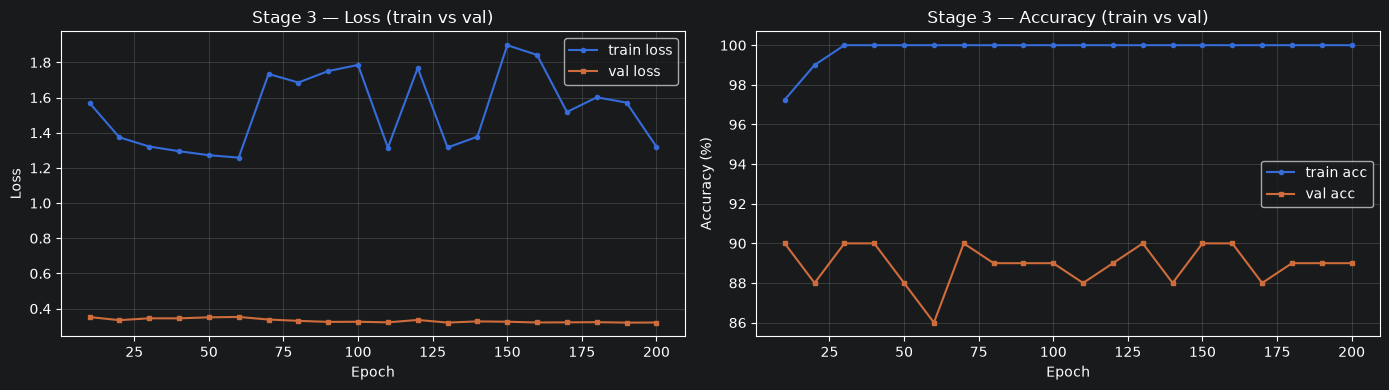

In [9]:
# ================================================================
# Inference: TTA + 最終評価
# ================================================================

def tta_predict(clip_backbone, adapter, head, x, n_views=5, device=DEVICE):
    head.eval()
    def _identity(x): return x
    def _weak(x):     return weak_aug(x)
    def _strong(x):   return strong_aug(x)
    def _strong2(x):  return strong_aug(x)
    def _strong3(x):  return strong_aug(x)
    aug_fns = [_identity, _weak, _strong, _strong2, _strong3]
    probs = []
    with torch.no_grad():
        for fn in aug_fns[:n_views]:
            xv = fn(x)
            feat = get_adapted_features(clip_backbone, adapter, xv, device)
            probs.append(F.softmax(head(feat), dim=-1))
    return torch.stack(probs).mean(0)


def evaluate_test(clip_backbone, adapter, head, test_imgs, test_lbls,
                  batch=128, label="", device=DEVICE):
    preds = []
    for i in tqdm(range(0, len(test_imgs), batch), desc=f"TTA [{label}]", position=0, leave=True):
        preds.append(tta_predict(clip_backbone, adapter, head,
                                 test_imgs[i:i+batch], device=device).argmax(1).cpu())
    preds = torch.cat(preds)
    acc = (preds == test_lbls).float().mean().item()
    print(f"[{label}] ★ TEST Accuracy (final): {acc*100:.2f}%")
    return acc


print("\n=== Final Test Evaluation (1回のみ) ===")
if history:
    best_ep = max(history, key=lambda h: h[4])
    print(f"  Best val_acc: {best_ep[4]*100:.1f}%  @ epoch {best_ep[0]}")

evaluate_test(clip_model, adapter, head,     test_imgs, test_lbls, label="Head (final)")
evaluate_test(clip_model, adapter, head_ema, test_imgs, test_lbls, label="Head (EMA)")

# 学習曲線プロット
try:
    import matplotlib.pyplot as plt
    if history:
        eps        = [h[0] for h in history]
        train_ls   = [h[1] for h in history]
        val_ls     = [h[2] for h in history]
        train_accs = [h[3]*100 for h in history]
        val_accs   = [h[4]*100 for h in history]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(eps, train_ls, label="train loss", marker="o", ms=3)
        axes[0].plot(eps, val_ls,   label="val loss",   marker="s", ms=3)
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
        axes[0].set_title("Stage 3 — Loss (train vs val)")
        axes[0].legend(); axes[0].grid(alpha=0.3)

        axes[1].plot(eps, train_accs, label="train acc", marker="o", ms=3)
        axes[1].plot(eps, val_accs,   label="val acc",   marker="s", ms=3)
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_title("Stage 3 — Accuracy (train vs val)")
        axes[1].legend(); axes[1].grid(alpha=0.3)

        plt.tight_layout(); plt.show()
except ImportError:
    pass


## 比較用 Baseline (簡易, 厳密なablationではない)

In [10]:
# ================================================================
# 比較用 baseline (厳密なablationではないが、提案手法の効果を
# 文脈づけるための最低限の比較)
# ----------------------------------------------------------------
#   (1) baseline_cnn      : labeled 500枚のみで学習した素のCNN
#                            (元のMNIST実験のbaselineに対応する比較対象)
#   (2) clip_supervised_only : CLIP+Adapter特徴 + labeled 500枚のみ
#                            (疑似ラベル・mixupなしで、CLIPの素の効果のみ測る)
# ================================================================

class SimpleCNN(nn.Module):
    """元のMNIST実験のbaseline CNNに相当する素朴なCNN (CIFAR-10向けにch数のみ調整)。"""
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, n_classes))

    def forward(self, x):
        return self.net(x)


def train_baseline_cnn(cfg, lx_train, ly_train, lx_val, ly_val, test_imgs, test_lbls,
                       epochs=100, device=DEVICE):
    """labeled 500枚のみで学習する素のCNN。CIFAR-10は32x32が本来の解像度なので
    ここだけ別途32x32にダウンサンプルして学習する (CLIP系は224x224固定)。"""
    down = T.Resize(32)
    lx_t = torch.stack([down(im) for im in lx_train])
    lx_v = torch.stack([down(im) for im in lx_val])

    model = SimpleCNN(cfg.n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    ce = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(lx_t, ly_train), batch_size=64, shuffle=True)

    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = ce(model(x), y)
            loss.backward(); opt.step()
        if (epoch + 1) % 20 == 0:
            model.eval()
            with torch.no_grad():
                pred = model(lx_v.to(device)).argmax(1).cpu()
            acc = (pred == ly_val).float().mean().item()
            best_acc = max(best_acc, acc)
            tqdm.write(f"[Baseline CNN ep {epoch+1}] val_acc={acc*100:.1f}%")

    model.eval()
    test_down = torch.stack([down(im.float()) for im in test_imgs])
    preds = []
    with torch.no_grad():
        for i in range(0, len(test_down), 256):
            preds.append(model(test_down[i:i+256].to(device)).argmax(1).cpu())
    preds = torch.cat(preds)
    test_acc = (preds == test_lbls).float().mean().item()
    print(f"[Baseline CNN] ★ TEST Accuracy: {test_acc*100:.2f}%")
    return test_acc


def train_clip_supervised_only(cfg, clip_backbone, adapter, lx_train, ly_train,
                               lx_val, ly_val, test_imgs, test_lbls, epochs=100):
    """CLIP+Adapter特徴のみ、labeled 500枚のみで学習 (疑似ラベル・mixupなし)。"""
    head = ClassifierHead(cfg).to(cfg.device)
    opt = torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
    ce = nn.CrossEntropyLoss()

    with torch.no_grad():
        feat_train = get_adapted_features(clip_backbone, adapter, lx_train, cfg.device)
        feat_val   = get_adapted_features(clip_backbone, adapter, lx_val,   cfg.device)

    loader = DataLoader(TensorDataset(feat_train, ly_train), batch_size=64, shuffle=True)
    best_acc = 0.0
    for epoch in range(epochs):
        head.train()
        for f, y in loader:
            f, y = f.to(cfg.device), y.to(cfg.device)
            opt.zero_grad()
            loss = ce(head(f), y)
            loss.backward(); opt.step()
        if (epoch + 1) % 20 == 0:
            head.eval()
            with torch.no_grad():
                pred = head(feat_val.to(cfg.device)).argmax(1).cpu()
            acc = (pred == ly_val).float().mean().item()
            best_acc = max(best_acc, acc)
            tqdm.write(f"[CLIP supervised-only ep {epoch+1}] val_acc={acc*100:.1f}%")

    head.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(test_imgs), 128):
            feat = get_adapted_features(clip_backbone, adapter,
                                        test_imgs[i:i+128], cfg.device)
            preds.append(head(feat).argmax(1).cpu())
    preds = torch.cat(preds)
    test_acc = (preds == test_lbls).float().mean().item()
    print(f"[CLIP supervised-only] ★ TEST Accuracy: {test_acc*100:.2f}%")
    return test_acc


print("\n=== Reference comparisons (簡易baseline) ===")
acc_baseline_cnn   = train_baseline_cnn(cfg, lx_train, ly_train, lx_val, ly_val, test_imgs, test_lbls)
acc_clip_only      = train_clip_supervised_only(cfg, clip_model, adapter, lx_train, ly_train,
                                                 lx_val, ly_val, test_imgs, test_lbls)
acc_proposed       = evaluate_test(clip_model, adapter, head_ema, test_imgs, test_lbls, label="Proposed (EMA)")

print("\n=== Summary ===")
print(f"  Baseline CNN (from scratch, 500 labels)        : {acc_baseline_cnn*100:.2f}%")
print(f"  CLIP+Adapter, supervised only (500 labels)     : {acc_clip_only*100:.2f}%")
print(f"  Proposed (pseudo-label + feature mixup)        : {acc_proposed*100:.2f}%")



=== Reference comparisons (簡易baseline) ===
[Baseline CNN ep 20] val_acc=20.0%
[Baseline CNN ep 40] val_acc=29.0%
[Baseline CNN ep 60] val_acc=24.0%
[Baseline CNN ep 80] val_acc=32.0%
[Baseline CNN ep 100] val_acc=31.0%
[Baseline CNN] ★ TEST Accuracy: 34.07%
[CLIP supervised-only ep 20] val_acc=86.0%
[CLIP supervised-only ep 40] val_acc=86.0%
[CLIP supervised-only ep 60] val_acc=85.0%
[CLIP supervised-only ep 80] val_acc=85.0%
[CLIP supervised-only ep 100] val_acc=86.0%
[CLIP supervised-only] ★ TEST Accuracy: 89.67%


TTA [Proposed (EMA)]:   0%|          | 0/79 [00:00<?, ?it/s]

[Proposed (EMA)] ★ TEST Accuracy (final): 92.27%

=== Summary ===
  Baseline CNN (from scratch, 500 labels)        : 34.07%
  CLIP+Adapter, supervised only (500 labels)     : 89.67%
  Proposed (pseudo-label + feature mixup)        : 92.27%
